In [172]:
from src.gmm import GMM
from src.dg import DataGenerator

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, logistic, t

import torch


## Data generating

In [173]:
N = 2000
d = 3

## Gaussian mixture with $k=5$

In [174]:
mu0 = torch.rand((5, 3)) * 2 - 1
sigma0 = torch.rand((5,3)) * 2
pi0 = torch.tensor([0.2, 0.3, 0.1, 0.3, 0.1])

dg = DataGenerator('gaussian_mixture', mu=mu0, sigma=sigma0, pi=pi0)
X, M = dg.generate(N, d)

## Normal with 
$$\Sigma = \begin{bmatrix} 1 & 0.7 & 0 \\ 0.7 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}$$

In [175]:
# param_vals
dist = 'Normal' # Logistic, Normal, Student t
alpha = 0.7

#df = 3 # for Student t in particular
dg = DataGenerator(dist, alpha)
X, M = dg.generate(N, d)

In [176]:
def true_quantile(dist, q=0.1, df=None):
    if dist == 'Normal':
        return norm.ppf(q)
    elif dist == 'Logistic':
        return logistic.ppf(q)
    elif dist == 'Student t':
        return t.ppf(q, df)

## Iterative EM

In [177]:
# GMM settings
cov_type = 'id' # diag, id, uni_diag, uni_id
n_k = 100
start = 0
step = 1
n_mc = 100
n_samples = 2000

choice of k = 100


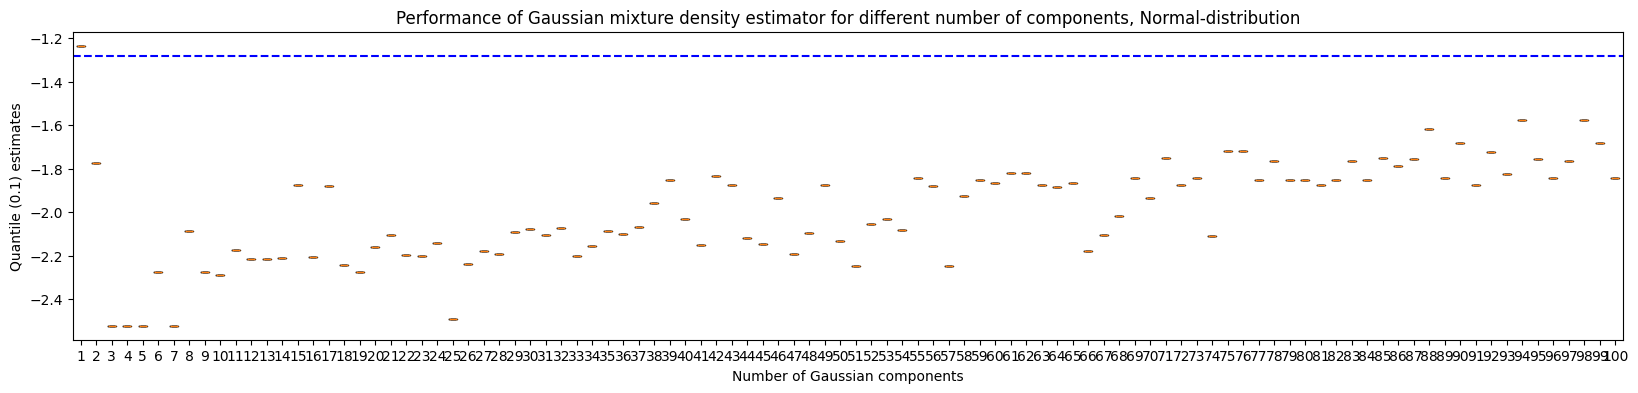

In [178]:
gmm = GMM(X, M, cov_type)
mu, sigma, pi, kk, q_x1, corr, loglik, aic, bic = gmm.iterEM(n_k, start, step, n_mc, n_samples, criterion='aic')

#Plot
positions = np.array(kk)
plt.figure(figsize=(20, 4))
plt.boxplot(q_x1.T, positions=positions)

plt.axhline(y=norm.ppf(0.1), color='blue', linestyle='--')
plt.xlabel("Number of Gaussian components")
plt.ylabel("Quantile (0.1) estimates of X1")
plt.xticks(positions, positions.astype(int))
plt.title(f'Performance of Gaussian mixture density estimator for different number of components, {dist}-distribution')
plt.show()

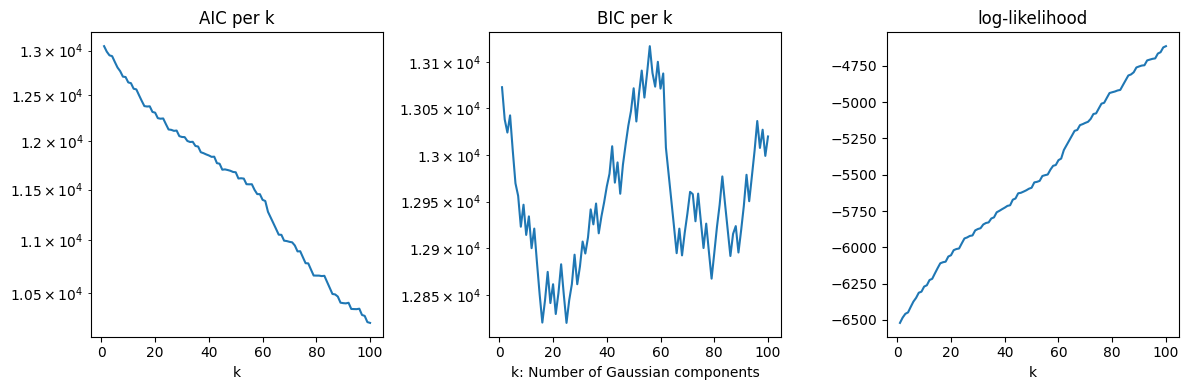

In [179]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].plot(kk, aic)
axs[0].set_yscale('log')
axs[0].set_xlabel('k')
axs[0].set_title('AIC per k')

axs[1].plot(kk, bic)
axs[1].set_yscale('log')
axs[1].set_xlabel('k: Number of Gaussian components')
axs[1].set_title('BIC per k')

axs[2].plot(kk, loglik)
axs[2].set_xlabel('k')
axs[2].set_title('log-likelihood')

plt.tight_layout()
plt.show()

In [180]:
def energy_distance(X, Y):
    """
    Compute the (squared) energy distance between two samples X ~ P, Y ~ Q.
    X: tensor of shape (n, d)
    Y: tensor of shape (m, d)
    
    E(P, Q) = 2 * E||X - Y|| - E||X - X'|| - E||Y - Y'||
    """
    X = X.double()
    Y = Y.double()

    n, m = X.shape[0], Y.shape[0]

    # Pairwise distances
    d_XY = torch.cdist(X, Y, p=2)      # (n, m)
    d_XX = torch.cdist(X, X, p=2)      # (n, n)
    d_YY = torch.cdist(Y, Y, p=2)      # (m, m)

    term_XY = d_XY.mean()

    # exclude diagonal (i.e. X_i vs X_i, which is 0 and shouldn't bias things,
    # but standard practice is to use the unbiased version excluding self-pairs)
    term_XX = (d_XX.sum() - d_XX.diagonal().sum()) / (n * (n - 1))
    term_YY = (d_YY.sum() - d_YY.diagonal().sum()) / (m * (m - 1))

    return 2 * term_XY - term_XX - term_YY


# Example usage:
# data: tensor of shape (n, 3)
# samples: sample_gmm(mu, sigma, pi, param_vals['n_new'])  -> tensor of shape (m, 3)

ed = energy_distance(X, gmm.sample_gmm(mu, sigma, pi, n_samples))
print(f"Energy distance: {ed.item():.4f}")

Energy distance: 0.3039
